In [24]:
# ! pip install wordcloud

In [71]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk

from collections import Counter
from gensim.corpora.dictionary import Dictionary
from gensim.models import LdaModel
from pprint import pprint
from pathlib import Path
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from tqdm import tqdm
import contractions
from nltk import pos_tag

In [72]:
path_dataset_gilda = "/Users/szonjapike/Desktop/BDS/Block_5/NLP/Project/"
#path_dataset_alvaro = ...

path_dataset = path_dataset_gilda # change accordingly

# 1. Load the dataset

In [73]:
# Load the final dataset that we got in 2. Load Speeches
final_df = pd.read_csv(os.path.join(path_dataset, "Final_df.csv"))
final_df

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_no_postagging_expanded,cleaned_speeches_no_postagging_no_expanded,cleaned_speeches_postagging_no_expanded,cleaned_speeches_postagging_expanded
0,45,1990,NZL,"﻿\nI should like to congratulate you, Sir, on ...",145,3512,4,like congratulate sir election presidency time...,like congratulate sir election presidency time...,like congratulate sir election presidency time...,like congratulate sir election presidency time...
1,45,1990,EGY,"﻿First of all, I would like to extend may dele...",76,2532,1,first would like extend may delegation persona...,first would like extend may delegation persona...,first like extend delegation personal warm con...,first like extend delegation personal warm con...
2,45,1990,CPV,﻿I should like to begin by offering Mr. de Mar...,71,2432,2,like begin offering mr marco sincere congratul...,like begin offering mr marco sincere congratul...,like begin offer mr sincere congratulation ele...,like begin offer mr sincere congratulation ele...
3,45,1990,UGA,"﻿In 1967, I had the privilege of addressing th...",132,3508,1,1967 privilege address assembly forty-second s...,1967 privilege address assembly forty-second s...,privilege address assembly forty-second sessio...,privilege address assembly forty-second sessio...
4,45,1990,NLD,"﻿\nMay I, first of all, extend to Mr. de Marco...",167,4134,4,may first extend mr marco congratulation elect...,may first extend mr marco congratulation elect...,first extend mr congratulation election presid...,first extend mr congratulation election presid...
...,...,...,...,...,...,...,...,...,...,...,...
6434,79,2024,CIV,Mr President of the 79th Session of the United...,41,1206,2,lady gentleman head state government secretary...,lady gentleman head state government secretary...,lady gentleman head state government secretary...,lady gentleman head state government secretary...
6435,79,2024,HND,"Madam President of this General Assembly, \nM...",54,1367,2,madam president general assembly mr secretary-...,madam president general assembly mr secretary-...,madam president general assembly mr secretary-...,madam president general assembly mr secretary-...
6436,79,2024,MKD,Distinguished President of the United Nations ...,101,2804,3,lady gentleman invite address 79th general deb...,lady gentleman invite address 79th general deb...,lady gentleman invite address general debate p...,lady gentleman invite address general debate p...
6437,79,2024,KOR,"Mr. President,\nMr. Secretary-General,\nDistin...",31,821,4,mr president mr secretary-general distinguish ...,mr president mr secretary-general distinguish ...,mr president mr secretary-general distinguishe...,mr president mr secretary-general distinguishe...


We will use the df: **extended and no post tagging**

- Keeps all semantically relevant words in different situations

    → No POS filtering ensures we retain adjectives, adverbs, and auxiliary/modal verbs (e.g., "urgent", "together", "must") that shape political discourse around climate change

- Expands contradictions for clarity

- Ideal for measuring relative attention 

    → We're interested in how much countries talk about climate relative in comparisoon to other country groups

- Aligns with standard gensum LDA expectations 

    → Works well with bag-of-words models, which assume unfiltered vocabulary (except stopwords and noise).



# 2. Keyword Assisted Topic Modelling (KeyATM)

In [74]:
#### ADD MORE WORDS FROM THE SECOND PAPER 
# These key words were taken from the UN paper and are related to the SDGs 12, 13, 14, and 1
climate_keywords = set([
    # SDG 12
    'sustainable consumption', 'sustainable production', 'resource efficiency',
    'waste management', 'recycling', 'supply chain', 'circular economy',
    'responsible consumption',
    
    # SDG 13
    'climate change', 'global warming', 'greenhouse gas', 'emissions',
    'carbon dioxide', 'climate action', 'climate resilience', 'climate mitigation',
    
    # SDG 14
    'oceans', 'marine', 'coastal', 'sea', 'seas', 'marine resources', 'fisheries',
    'aquaculture', 'marine pollution',
    
    # SDG 15
    'biodiversity', 'ecosystems', 'ecosystem', 'land', 'forest', 'forests', 'wildlife',
    'habitat', 'deforestation', 'desertification', 'species'
])


In [75]:
# Count mentions of any climate-related keywords in the speeches
def count_climate_mentions(text, keywords):
    tokens = text.split()
    token_counts = Counter(tokens)
    joined_text = " ".join(tokens)

    total = 0
    for kw in keywords:
        if ' ' in kw:
            total += joined_text.count(kw)
        else:
            total += token_counts[kw]
    return total


Prepare the dataframe

In [76]:
# Just take the interested preprocessed column from the final_df
df_topic_modelling = final_df.iloc[:, :-3]   # the no pos tagging, extended one

# Create bins each 5 years
df_topic_modelling['YearBin'] = (df_topic_modelling['Year'] // 5) * 5
df_topic_modelling

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_no_postagging_expanded,YearBin
0,45,1990,NZL,"﻿\nI should like to congratulate you, Sir, on ...",145,3512,4,like congratulate sir election presidency time...,1990
1,45,1990,EGY,"﻿First of all, I would like to extend may dele...",76,2532,1,first would like extend may delegation persona...,1990
2,45,1990,CPV,﻿I should like to begin by offering Mr. de Mar...,71,2432,2,like begin offering mr marco sincere congratul...,1990
3,45,1990,UGA,"﻿In 1967, I had the privilege of addressing th...",132,3508,1,1967 privilege address assembly forty-second s...,1990
4,45,1990,NLD,"﻿\nMay I, first of all, extend to Mr. de Marco...",167,4134,4,may first extend mr marco congratulation elect...,1990
...,...,...,...,...,...,...,...,...,...
6434,79,2024,CIV,Mr President of the 79th Session of the United...,41,1206,2,lady gentleman head state government secretary...,2020
6435,79,2024,HND,"Madam President of this General Assembly, \nM...",54,1367,2,madam president general assembly mr secretary-...,2020
6436,79,2024,MKD,Distinguished President of the United Nations ...,101,2804,3,lady gentleman invite address 79th general deb...,2020
6437,79,2024,KOR,"Mr. President,\nMr. Secretary-General,\nDistin...",31,821,4,mr president mr secretary-general distinguish ...,2020


In [77]:
# Count the number of climate keywords for each row
df_topic_modelling['ClimateMentions'] = df_topic_modelling['cleaned_speeches_no_postagging_expanded'].apply(
    lambda x: count_climate_mentions(x, climate_keywords)
)
df_topic_modelling

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_no_postagging_expanded,YearBin,ClimateMentions
0,45,1990,NZL,"﻿\nI should like to congratulate you, Sir, on ...",145,3512,4,like congratulate sir election presidency time...,1990,6
1,45,1990,EGY,"﻿First of all, I would like to extend may dele...",76,2532,1,first would like extend may delegation persona...,1990,6
2,45,1990,CPV,﻿I should like to begin by offering Mr. de Mar...,71,2432,2,like begin offering mr marco sincere congratul...,1990,2
3,45,1990,UGA,"﻿In 1967, I had the privilege of addressing th...",132,3508,1,1967 privilege address assembly forty-second s...,1990,0
4,45,1990,NLD,"﻿\nMay I, first of all, extend to Mr. de Marco...",167,4134,4,may first extend mr marco congratulation elect...,1990,2
...,...,...,...,...,...,...,...,...,...,...
6434,79,2024,CIV,Mr President of the 79th Session of the United...,41,1206,2,lady gentleman head state government secretary...,2020,3
6435,79,2024,HND,"Madam President of this General Assembly, \nM...",54,1367,2,madam president general assembly mr secretary-...,2020,2
6436,79,2024,MKD,Distinguished President of the United Nations ...,101,2804,3,lady gentleman invite address 79th general deb...,2020,4
6437,79,2024,KOR,"Mr. President,\nMr. Secretary-General,\nDistin...",31,821,4,mr president mr secretary-general distinguish ...,2020,0


In [78]:
# Make sure that columns are suitable for plotting --> no space
df_topic_modelling.columns
df_topic_modelling.rename(columns = {'Income Level': 'IncomeLevel'}, inplace = True)

# Group the data by the income levels in each bin and count the mentions
grouped_totals = df_topic_modelling.groupby(['IncomeLevel', 'YearBin'])['ClimateMentions'].sum().reset_index()
grouped_totals

,IncomeLevel,YearBin,ClimateMentions
0,1,1990,490
1,1,1995,377
2,1,2000,265
3,1,2005,689
4,1,2010,464
5,1,2015,595
6,1,2020,582
7,2,1990,639
8,2,1995,590
9,2,2000,392


### Plot the frequency of keyword mentions per group in each bin

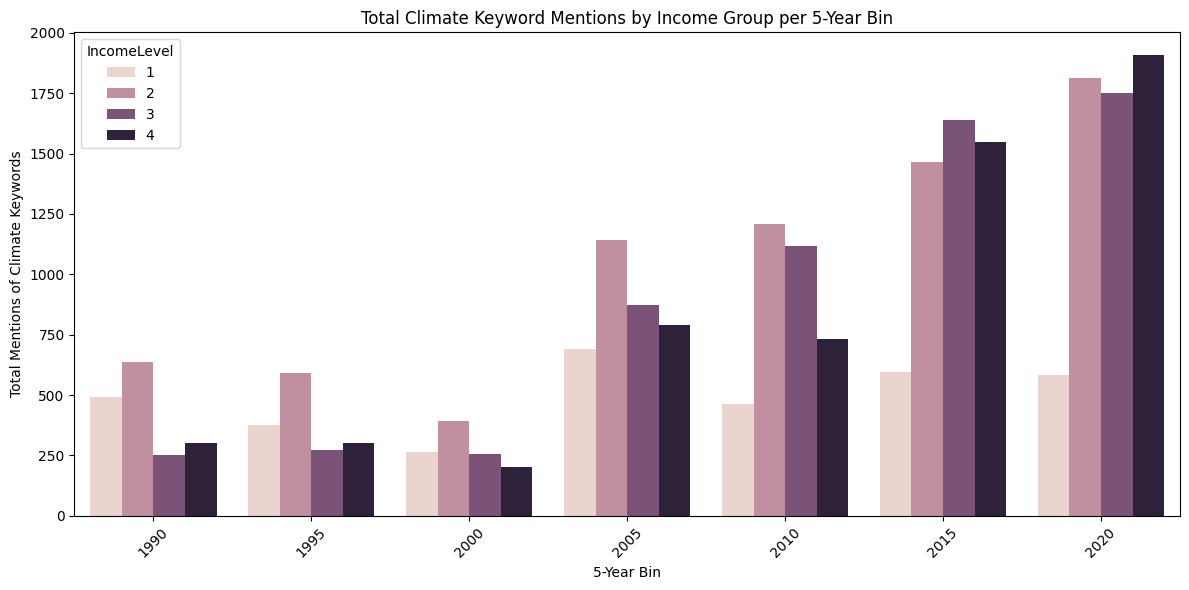

In [79]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped_totals,
    x='YearBin',
    y='ClimateMentions',
    hue='IncomeLevel'
)
plt.title('Total Climate Keyword Mentions by Income Group per 5-Year Bin')
plt.xlabel('5-Year Bin')
plt.ylabel('Total Mentions of Climate Keywords')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Word Cloud

In [81]:
# Count the frequency for each keyword
def extract_climate_words(text, keywords):
    if not isinstance(text, str):
        return []
    tokens = text.split()
    token_text = " ".join(tokens)
    result = []

    for kw in keywords:
        if ' ' in kw:
            count = token_text.count(kw)
            result.extend([kw] * count)
        else:
            count = tokens.count(kw)
            result.extend([kw] * count)
    
    return result

# Apply to your text column and save as a list of climate words
df_topic_modelling['ClimateWords'] = df_topic_modelling['cleaned_speeches_no_postagging_expanded'].apply(
    lambda x: extract_climate_words(x, climate_keywords)
)

df_topic_modelling

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,IncomeLevel,cleaned_speeches_no_postagging_expanded,YearBin,ClimateMentions,ClimateWords
0,45,1990,NZL,"﻿\nI should like to congratulate you, Sir, on ...",145,3512,4,like congratulate sir election presidency time...,1990,6,"[biodiversity, sea, greenhouse gas, ecosystem,..."
1,45,1990,EGY,"﻿First of all, I would like to extend may dele...",76,2532,1,first would like extend may delegation persona...,1990,6,"[sea, sea, desertification, land, land, land]"
2,45,1990,CPV,﻿I should like to begin by offering Mr. de Mar...,71,2432,2,like begin offering mr marco sincere congratul...,1990,2,"[desertification, desertification]"
3,45,1990,UGA,"﻿In 1967, I had the privilege of addressing th...",132,3508,1,1967 privilege address assembly forty-second s...,1990,0,[]
4,45,1990,NLD,"﻿\nMay I, first of all, extend to Mr. de Marco...",167,4134,4,may first extend mr marco congratulation elect...,1990,2,"[deforestation, deforestation]"
...,...,...,...,...,...,...,...,...,...,...,...
6434,79,2024,CIV,Mr President of the 79th Session of the United...,41,1206,2,lady gentleman head state government secretary...,2020,3,"[climate action, climate change, climate change]"
6435,79,2024,HND,"Madam President of this General Assembly, \nM...",54,1367,2,madam president general assembly mr secretary-...,2020,2,"[deforestation, forest]"
6436,79,2024,MKD,Distinguished President of the United Nations ...,101,2804,3,lady gentleman invite address 79th general deb...,2020,4,"[greenhouse gas, climate action, climate chang..."
6437,79,2024,KOR,"Mr. President,\nMr. Secretary-General,\nDistin...",31,821,4,mr president mr secretary-general distinguish ...,2020,0,[]


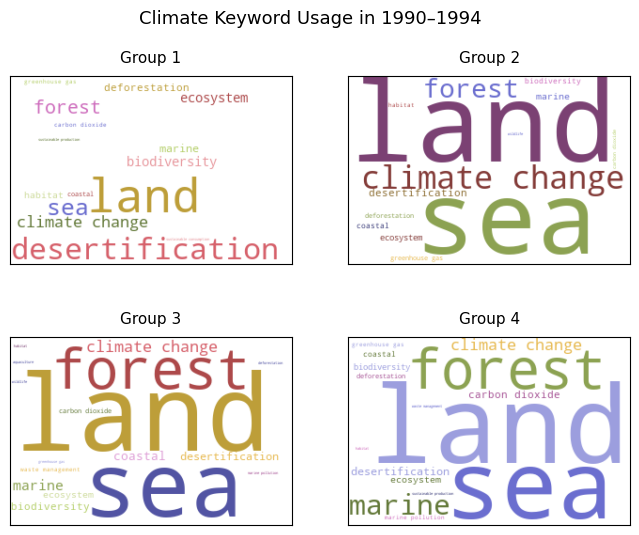

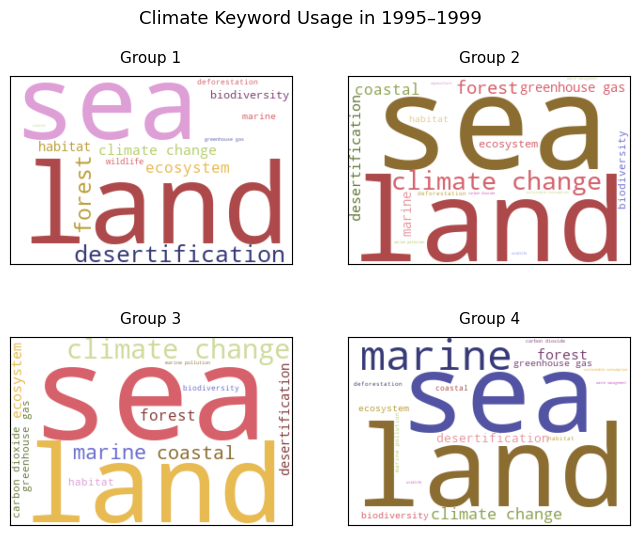

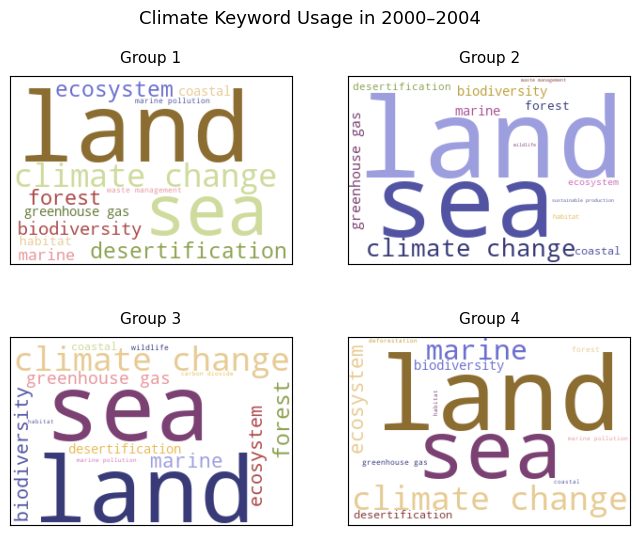

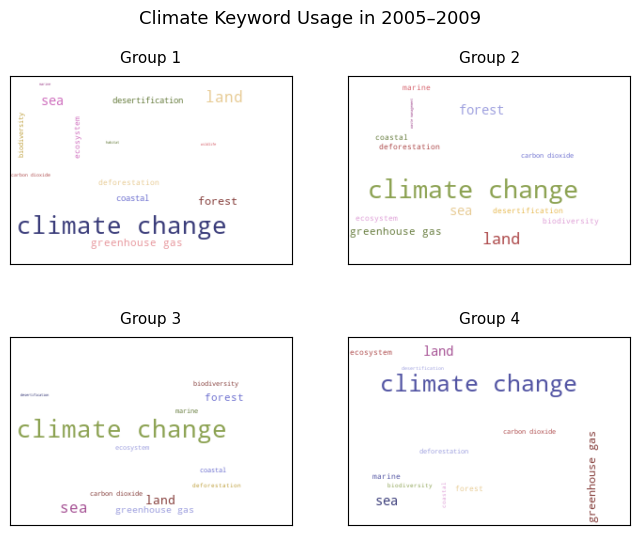

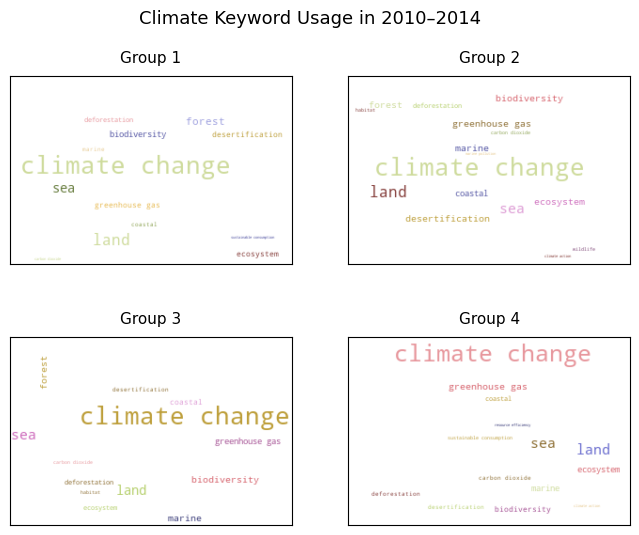

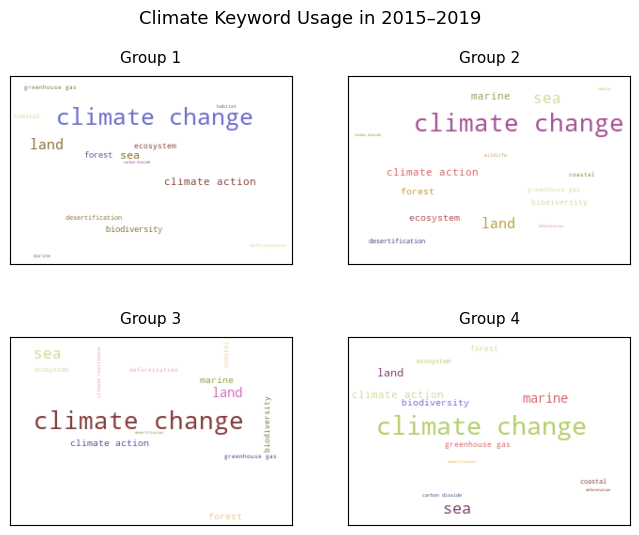

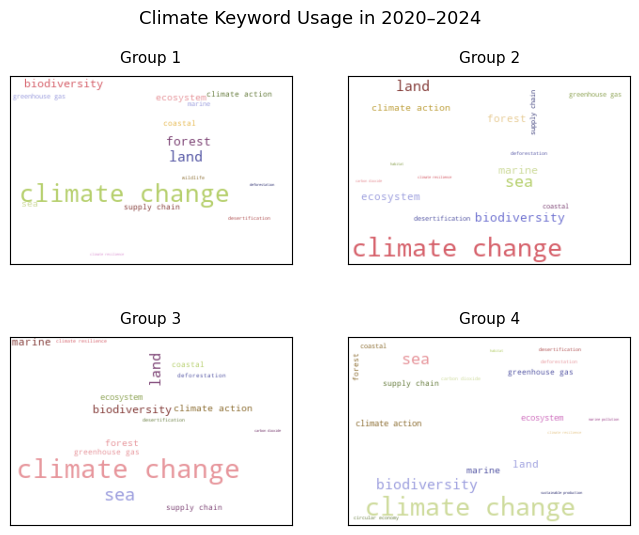

In [82]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

bins = sorted(df_topic_modelling['YearBin'].unique())
groups = sorted(df_topic_modelling['IncomeLevel'].unique())

for year_bin in bins:
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f"Climate Keyword Usage in {year_bin}–{year_bin+4}", fontsize=13)

    for i, group in enumerate(groups):
        row, col = divmod(i, 2)
        ax = axes[row][col]

        subset = df_topic_modelling[
            (df_topic_modelling['IncomeLevel'] == group) &
            (df_topic_modelling['YearBin'] == year_bin)
        ]

        climate_words = sum(subset['ClimateWords'].tolist(), [])

        if not climate_words:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"Group {group} — No data", fontsize=11, pad=10)
            ax.set_frame_on(True)
            continue

        freq = dict(Counter(climate_words))
        wc = WordCloud(
            width=300, height=200,
            background_color='white',
            colormap='tab20b',
            max_words=50,
            contour_color='black',
            contour_width=1
        ).generate_from_frequencies(freq)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Group {group}", fontsize=11, pad=10)
        ax.set_frame_on(True)

    
    plt.subplots_adjust(hspace=0.3, wspace=0.2) # space out the plots
    
    plt.show()


# LDA

In [13]:
# filter only the preprocessing of extended and no pos tagging
df_lda = final_df.iloc [:, :-3]
df_lda

# Create sub dataframes per income level
df_lda_1 = df_lda[df_lda['Income Level'] == 1]
df_lda_2 = df_lda[df_lda['Income Level'] == 2]
df_lda_3 = df_lda[df_lda['Income Level'] == 3]
df_lda_4 = df_lda[df_lda['Income Level'] == 4]

In [19]:
# LDA function from the teacher in collab
def obtain_lda_model(texts_list, alpha = 'auto'):
    """
        Input: texts_list of format [[sent_1], ..., [sent_n]] where for each sent_i = [word_1, ..., word_n]
        Output: LDA model (gensim model)
        Function: Create a dictonary object that is used to create an LDA model.
    """
    dictionary = Dictionary(texts_list) # Construct word <-> id mappings used by the LDA model
    # Filter words that occur in less than 15 the documents (no_above)
    # Filter words that occur in less than 50% of the provided documents
    dictionary.filter_extremes(no_below=15, no_above=0.5, keep_n=100000)
    common_corpus = [dictionary.doc2bow(text) for text in texts_list]
    _ = dictionary[0] # need this line to force-load the data in the kernel
    id2word = dictionary.id2token

    # For further reading on the documentation of the LdaModel please see: https://radimrehurek.com/gensim/models/ldamodel.html
    lda = LdaModel(common_corpus, id2word=id2word,num_topics=20, decay = 0.6, minimum_probability=0.001, alpha = alpha)
    return [lda,common_corpus,dictionary]

### LDA for the income group 1

In [20]:
# create a corpus of the speeches
texts_list = [[word for word in doc.split()] for doc in df_lda_1['cleaned_speeches_no_postagging_expanded']]

[lda_model, corpus, dictionary] = obtain_lda_model(texts_list)

# print top keywords per topic
pprint(lda_model.print_topics(num_topics=15, num_words=10))


[(9,
  '0.003*"central" + 0.002*"debt" + 0.002*"child" + 0.002*"union" + '
  '0.002*"unity" + 0.002*"congo" + 0.002*"mission" + 0.002*"century" + '
  '0.002*"solidarity" + 0.002*"climate"'),
 (13,
  '0.003*"nuclear" + 0.003*"weapon" + 0.003*"burundi" + 0.003*"somalia" + '
  '0.002*"climate" + 0.002*"solidarity" + 0.002*"continent" + '
  '0.002*"afghanistan" + 0.002*"woman" + 0.002*"plan"'),
 (2,
  '0.003*"weapon" + 0.003*"union" + 0.002*"congo" + 0.002*"central" + '
  '0.002*"settlement" + 0.002*"somalia" + 0.002*"century" + 0.002*"burundi" + '
  '0.002*"debt" + 0.002*"millennium"'),
 (10,
  '0.003*"cent" + 0.003*"weapon" + 0.003*"let" + 0.002*"nuclear" + 0.002*"per" '
  '+ 0.002*"union" + 0.002*"child" + 0.002*"century" + 0.002*"continent" + '
  '0.002*"health"'),
 (12,
  '0.004*"mali" + 0.004*"burundi" + 0.003*"union" + 0.003*"congo" + '
  '0.002*"climate" + 0.002*"woman" + 0.002*"central" + 0.002*"weapon" + '
  '0.002*"violence" + 0.002*"plan"'),
 (17,
  '0.002*"central" + 0.002*"un

### LDA for income group 2

In [21]:
# create a corpus of the speeches
texts_list = [[word for word in doc.split()] for doc in df_lda_2['cleaned_speeches_no_postagging_expanded']]

[lda_model, corpus, dictionary] = obtain_lda_model(texts_list)

# print top keywords per topic
pprint(lda_model.print_topics(num_topics=15, num_words=10))

[(14,
  '0.003*"central" + 0.003*"south" + 0.003*"per" + 0.002*"america" + '
  '0.002*"cent" + 0.002*"history" + 0.002*"century" + 0.002*"say" + '
  '0.002*"island" + 0.002*"freedom"'),
 (9,
  '0.003*"africa" + 0.002*"palestinian" + 0.002*"african" + 0.002*"island" + '
  '0.002*"child" + 0.002*"israel" + 0.002*"combat" + 0.002*"per" + '
  '0.002*"south" + 0.002*"weapon"'),
 (19,
  '0.004*"island" + 0.003*"weapon" + 0.002*"africa" + 0.002*"per" + '
  '0.002*"million" + 0.002*"convention" + 0.002*"south" + 0.002*"nuclear" + '
  '0.002*"military" + 0.002*"pacific"'),
 (16,
  '0.003*"africa" + 0.002*"bosnia" + 0.002*"territory" + 0.002*"south" + '
  '0.002*"freedom" + 0.002*"iraq" + 0.002*"israel" + 0.002*"cent" + '
  '0.002*"century" + 0.002*"weapon"'),
 (5,
  '0.003*"iraq" + 0.003*"palestinian" + 0.003*"plan" + 0.003*"island" + '
  '0.003*"africa" + 0.002*"middle" + 0.002*"weapon" + 0.002*"cent" + '
  '0.002*"solidarity" + 0.002*"child"'),
 (8,
  '0.003*"africa" + 0.003*"weapon" + 0.002*